In [1]:
import numpy as np
from cr3bp import (
    create_earth_moon_system,
    plot_trajectory,
    decision_to_state0,
    evaluate,
    grid_search_method
)

In [2]:
em = create_earth_moon_system()
print(em.info())

CR3BP System Information:
  Primary 1 mass: 5.972e+24 kg
  Primary 2 mass: 7.342e+22 kg
  Primary 1 radius: 6.371e+06 m
  Primary 2 radius: 1.737e+06 m
  Total mass: 6.045e+24 kg
  Distance: 3.844e+08 m (384400.0 km)
  Mass parameter μ: 0.012145

Characteristic scales:
  Length (l*): 3.844e+08 m (384400.0 km)
  Time (t*): 3.752e+05 s (4.343 days)
  Velocity (v*): 1.025e+03 m/s (1.025 km/s)
  Acceleration (a*): 2.731e-03 m/s^2
  Period: 27.285 days
None


In [3]:
leo_alt_m=463e3
lmo_alt_m=100e3

In [4]:
x0 = np.array([4.065625, 3.009677, -0.645494, 0.80645161])
state0 = decision_to_state0(em, x0, leo_alt_m)

In [5]:
tof = x0[3]
t_span = (0,tof)
t_eval = np.linspace(0, tof, 1000)
states, ts, sol = em.solve(state0, t_span, t_eval)

In [6]:
constraint_value, objective_value = evaluate(em, x0, leo_alt_m=leo_alt_m, lmo_alt_m=lmo_alt_m)
print(constraint_value, objective_value)

0.006045809588500964 4.269066155928515


In [7]:
print(1e6/em.l_star)

0.0026014568158168575


Distance from moon : 2424 km
Distance from LMO of 100km : 2324 km
Total Delta_v required : 4.37 km/s


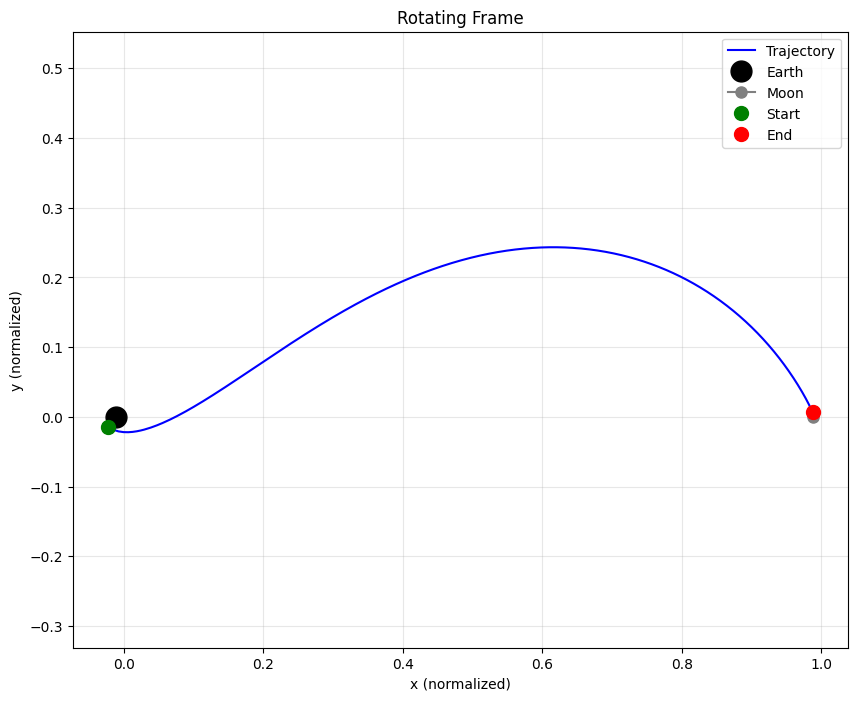

In [8]:
pos_f = states[:,-1][0:3]
#print(f"Rocket Final Pos in Rotating Frame (normalized units): {pos_f}")
print(f"Distance from moon : {1e-3*(constraint_value*em.l_star + lmo_alt_m):.0f} km")
print(f"Distance from LMO of 100km : {constraint_value*em.l_star * 1e-3:.0f} km")
print(f"Total Delta_v required : {objective_value*em.v_star * 1e-3:.2f} km/s")
plot_trajectory(states, em.mu, t_eval, frame="Rotating")

In [ ]:
dec_var_ranges = [[3.8, 4.4],[3.5, 4.1], [-0.5, 0.5], [0.6, 1]]

In [10]:
optimals = grid_search_method(em, dec_var_ranges, 0.02, leo_alt_m, lmo_alt_m)
optimal_delta_v = optimals[0]
optimal_theta = optimals[1]
optimal_delta_v_angle = optimals[2]
optimal_tof = optimals[3]
print(f"Optimal Delta_v from Grid Search: {optimal_delta_v*em.v_star*1e-3:.2f} km/s")
print(f"Optimal Theta from Grid Search: {optimal_theta:.2f} rad")
print(f"Optimal Delta_v Angle from Grid Search: {optimal_delta_v_angle:.2f} rad")
print(f"Optimal Time of Flight from Grid Search: {optimal_tof:.2f} s")

Performing grid search with 5 x 5 x 5 x 5 = 625 grid points...
Estimated time is 5.21 minutes (assuming 1s per evaluation)
Iteration: 26/625
Evaluating grid point: Theta=3.80 rad, Delta_v=3.50, Delta_v_angle=0.00 rad, TOF=0.60 s => Distance to LMO=363971.48 km, Total Delta_v=5.91 km/s
Iteration: 27/625
Evaluating grid point: Theta=3.80 rad, Delta_v=3.50, Delta_v_angle=0.00 rad, TOF=0.70 s => Distance to LMO=333910.69 km, Total Delta_v=4.71 km/s
Iteration: 28/625
Evaluating grid point: Theta=3.80 rad, Delta_v=3.50, Delta_v_angle=0.00 rad, TOF=0.80 s => Distance to LMO=372327.02 km, Total Delta_v=9.73 km/s
Iteration: 29/625
Evaluating grid point: Theta=3.80 rad, Delta_v=3.50, Delta_v_angle=0.00 rad, TOF=0.90 s => Distance to LMO=340296.57 km, Total Delta_v=5.13 km/s
Iteration: 30/625
Evaluating grid point: Theta=3.80 rad, Delta_v=3.50, Delta_v_angle=0.00 rad, TOF=1.00 s => Distance to LMO=331222.67 km, Total Delta_v=5.18 km/s
Iteration: 31/625
Evaluating grid point: Theta=3.80 rad, Delta

TypeError: 'NoneType' object is not subscriptable